# Airbnb NYC Listings — Exploratory Data Analysis Case Study

## Introduction

The purpose of this project is to analyze Airbnb listings in New York City in order to understand the key factors that influence pricing and market performance. By exploring listing characteristics such as room type, neighborhood, availability, and review activity, this analysis aims to uncover actionable insights that can help hosts optimize their pricing strategies and improve competitiveness.

**Business Question:**

> What factors influence Airbnb listing prices in New York City, and how can hosts optimize their pricing strategies?

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
airbnb_listings = pd.read_csv('AB_NYC/AB_NYC_2019.csv')
airbnb_listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Dataset Overview

The dataset contains Airbnb listings in New York City, including pricing, location, room type, review statistics, and availability information.

Key variables analyzed include:

* `price`
* `room_type`
* `neighbourhood_group`
* `number_of_reviews`
* `availability_365`
* `last_review`

This project focuses on exploratory analysis rather than predictive modeling.

In [127]:
airbnb_listings.shape

(48895, 16)

In [128]:
airbnb_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [129]:
## Describtion of the data and detect the distribution of the price
# print(airbnb_listings.describe())
print(airbnb_listings['price'].mean())
print(airbnb_listings['price'].median())
print(airbnb_listings['price'].mode())
print(airbnb_listings['price'].skew())

152.7206871868289
106.0
0    100
Name: price, dtype: int64
19.118938995046033


** `Mean > Median > Mode` **
### So the distribution is a `{right skewed}`

In [130]:
## Work with null values
airbnb_listings.isna().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [131]:
## finding the null values reasons in reviews columns
review_cols = airbnb_listings.filter(like='review').columns
airbnb_listings.loc[
    airbnb_listings['number_of_reviews'] == 0,
    review_cols
]


,number_of_reviews,last_review,reviews_per_month
2,0,NaN,NaN
19,0,NaN,NaN
26,0,NaN,NaN
36,0,NaN,NaN
38,0,NaN,NaN
...,...,...,...
48890,0,NaN,NaN
48891,0,NaN,NaN
48892,0,NaN,NaN
48893,0,NaN,NaN


### Hot note ! 
`Because there is no any number of reviews, so the hosts is a new non previous booked so there is no last_reviews, reviews_per_month`

In [132]:
## finding the percentage of the missing data rows from all 
(airbnb_listings.isna().sum().max() / airbnb_listings.shape[0]) * 100

np.float64(20.55833929849678)

In [133]:
## fill missing values of reviews_per_month with 0 and name with unknown
airbnb_listings['reviews_per_month'] = airbnb_listings['reviews_per_month'].fillna(0)
airbnb_listings['host_name'] = airbnb_listings['host_name'].fillna('unknown')
airbnb_listings['name'] = airbnb_listings['name'].fillna('unknown')


In [134]:
airbnb_listings.isna().sum().sort_values(ascending=False)

last_review                       10052
id                                    0
host_id                               0
name                                  0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
host_name                             0
longitude                             0
room_type                             0
minimum_nights                        0
price                                 0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [135]:
airbnb_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Note: 
`The last_review must be a date not a string object`

In [136]:
## converting the type of last_review to datetime 
airbnb_listings['last_review'] = pd.to_datetime(airbnb_listings['last_review'])
airbnb_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

### New feature:
`Here I will make a new feature called 'has_review' 1 if yab otherwise is 0`

In [137]:
airbnb_listings['has_review'] = airbnb_listings['last_review'].notna().astype(int)
airbnb_listings['has_review']

0        1
1        1
2        0
3        1
4        1
        ..
48890    0
48891    0
48892    0
48893    0
48894    0
Name: has_review, Length: 48895, dtype: int64

#### After finishing the understanding of the data and data cleaning 
Next step is `EDA`

In [138]:
airbnb_listings[airbnb_listings.price > 8000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0,1
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0,1
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83,1
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0,1
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaT,0.00,1,83,0
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,18128455,Rum,Manhattan,Tribeca,40.72197,-74.00633,Entire home/apt,8500,30,2,2018-09-18,0.18,1,251,1
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaT,0.00,1,365,0


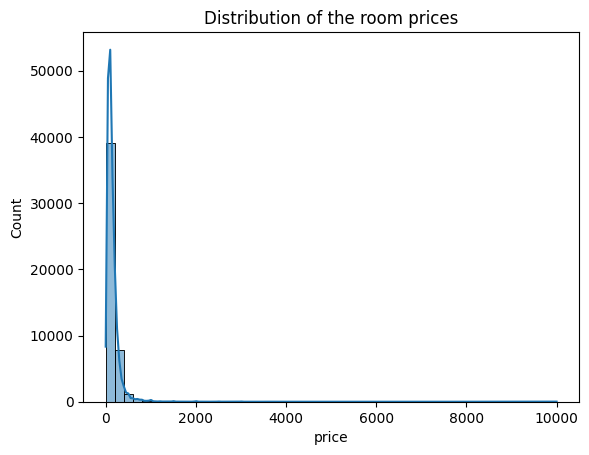

In [139]:
## Display the distribution of the room prices (Expected to be a right skewed)!! 
## let see 

plt.title('Distribution of the room prices')
sns.histplot(data=airbnb_listings['price'], bins=50, kde=True)
plt.show()

### `Detect the outliers using Interquantile Range IQR`

In [140]:
Q1 = airbnb_listings['price'].quantile(0.25)
Q3 = airbnb_listings['price'].quantile(0.75)

IQR = Q3 - Q1

lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR

outliers_iqr = airbnb_listings[(airbnb_listings['price'] < lower_b) | (airbnb_listings['price'] > upper_b)]

outliers_iqr

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review
61,15396,Sunny & Spacious Chelsea Apartment,60278,Petra,Manhattan,Chelsea,40.74623,-73.99530,Entire home/apt,375,180,5,2018-11-03,0.12,1,180,1
85,19601,perfect for a family or small group,74303,Maggie,Brooklyn,Brooklyn Heights,40.69723,-73.99268,Entire home/apt,800,1,25,2016-08-04,0.24,1,7,1
103,23686,2000 SF 3br 2bath West Village private townhouse,93790,Ann,Manhattan,West Village,40.73096,-74.00319,Entire home/apt,500,4,46,2019-05-18,0.55,2,243,1
114,26933,2 BR / 2 Bath Duplex Apt with patio! East Village,72062,Bruce,Manhattan,East Village,40.72540,-73.98157,Entire home/apt,350,2,7,2017-08-09,0.06,4,298,1
121,27659,3 Story Town House in Park Slope,119588,Vero,Brooklyn,South Slope,40.66499,-73.97925,Entire home/apt,400,2,16,2018-12-30,0.24,2,216,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48758,36420289,"Rustic Garden House Apt, 2 stops from Manhattan",73211393,LaGabrell,Queens,Long Island City,40.75508,-73.93258,Entire home/apt,350,2,0,NaT,0.00,1,364,0
48833,36450896,Brand New 3-Bed Apt in the Best Location of FiDi,29741813,Yue,Manhattan,Financial District,40.70605,-74.01042,Entire home/apt,475,2,0,NaT,0.00,1,64,0
48839,36452721,Massage Spa. Stay overnight. Authors Artist dr...,274079964,Richard,Brooklyn,Sheepshead Bay,40.59866,-73.95661,Private room,800,1,0,NaT,0.00,1,23,0
48842,36453160,LUXURY MANHATTAN PENTHOUSE+HUDSON RIVER+EMPIRE...,224171371,LuxuryApartmentsByAmber,Manhattan,Chelsea,40.75204,-74.00292,Entire home/apt,350,1,0,NaT,0.00,1,9,0


In [141]:
## outliers percentage 
len(outliers_iqr) / len(airbnb_listings) * 100  

6.078331117701197

## Note: 
`Even the median is 106 so the max-normal price values in range 200$`
`as we can see the outlier values affected on the total distibution shape`
#### So I will make a log1 transfomation to make a linear data increament
`ex: Exponential increasing [10 , 100 , 1000] -> after log1 will be [2.3, 4.6, 6.9] 'linear'`

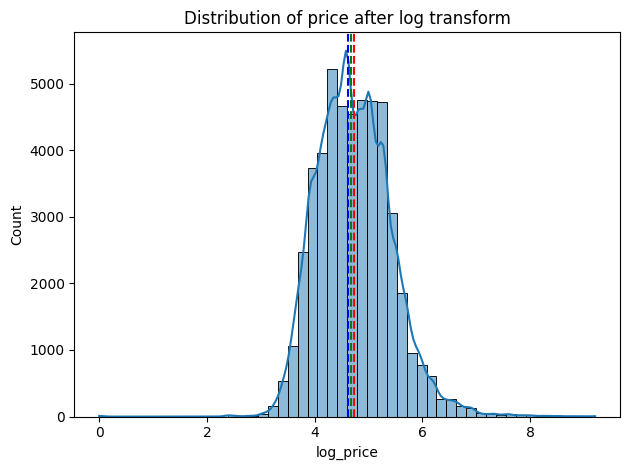

In [142]:
## make a log transformation 
airbnb_listings['log_price'] = np.log1p(airbnb_listings['price'])

mean = airbnb_listings['log_price'].mean()
median = airbnb_listings['log_price'].median()
mode = airbnb_listings['log_price'].mode()[0]

plt.title('Distribution of price after log transform')

sns.histplot(data=airbnb_listings['log_price'], bins=50, kde=True)

plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.axvline(median, color='green', linestyle='--', label='Median')
plt.axvline(mode, color='blue', linestyle='--', label='Mode')

plt.tight_layout()
plt.show()

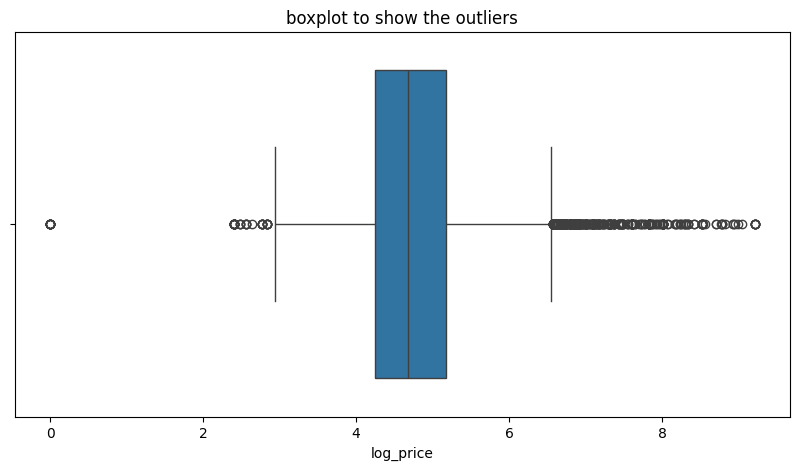

In [143]:
## boxplot to show the outliers
plt.figure(figsize=(10,5))
plt.title('boxplot to show the outliers')
sns.boxplot(x=airbnb_listings['log_price'])
plt.show()

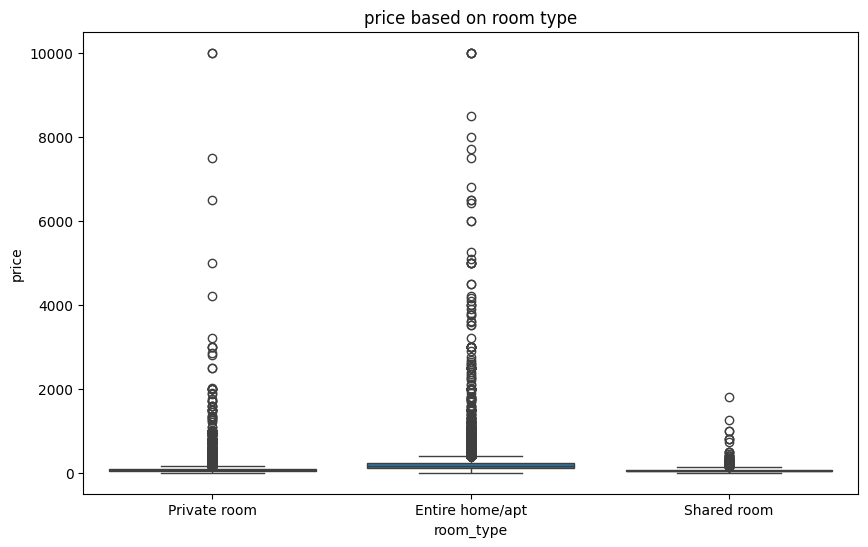

In [144]:
## boxplot for price based on room type
plt.figure(figsize=(10,6))
plt.title('price based on room type')
sns.boxplot(x='room_type', y='price', data=airbnb_listings)
plt.show()

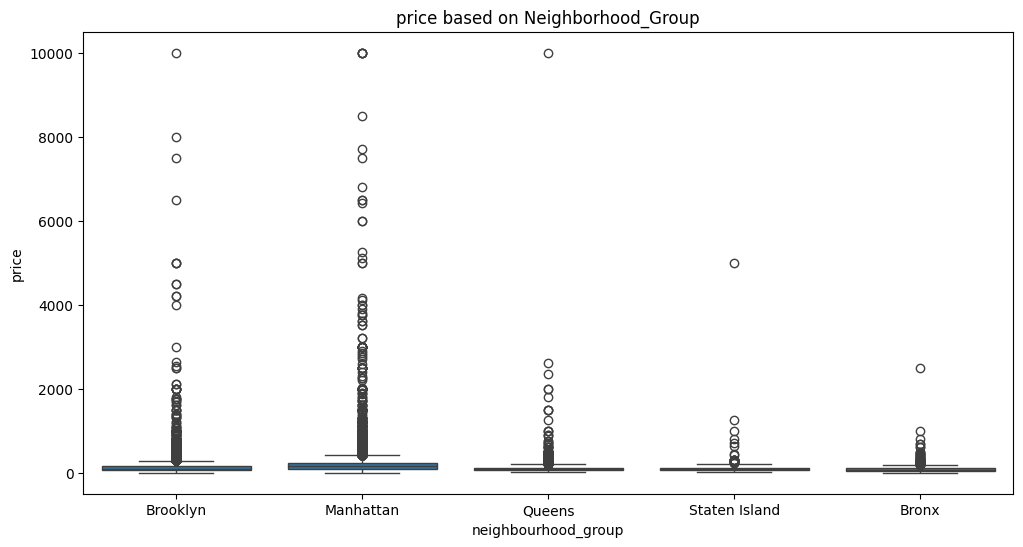

In [145]:
## boxplot for price based on Neighborhood_Group 
plt.figure(figsize=(12,6))
plt.title('price based on Neighborhood_Group')
sns.boxplot(x='neighbourhood_group', y='price', data=airbnb_listings)
plt.show()

## Data Cleaning

Several preprocessing steps were performed to improve data quality:

* Inspected dataset structure, spread, and missing values.
* Identified missing values in review-related columns.
* Investigated null patterns and determined that many missing review values corresponded to new or inactive listings.
* Preserved important listing records rather than removing large portions of data.
* Applied appropriate handling strategies for missing values depending on business context.
* Converted and corrected date-related fields for consistency.
* Assessed outliers using IQR and log transformation techniques.

Outlier analysis showed that approximately 6% of listings fell outside the interquartile range, indicating the presence of a premium pricing segment rather than purely erroneous records.


## `Analysis`

In [146]:
airbnb_listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,log_price
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,5.010635
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1,5.420535
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,0,5.017280
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,4.499810
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,1,4.394449


C:\Users\java\AppData\Local\Temp\ipykernel_11432\3118237418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roomPricesAvg, x='room_type', y='median_price', palette='summer')


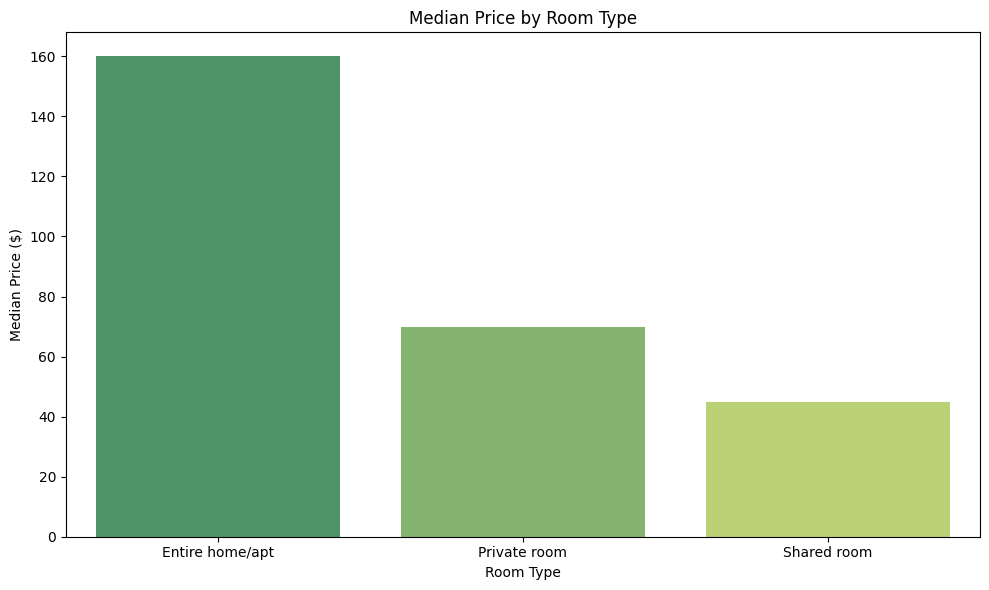

In [147]:
## room type average price — Fixed: removed conflicting color+palette, used proper DataFrame format
roomPricesAvg = airbnb_listings.groupby('room_type')['price'].median().reset_index()
roomPricesAvg.columns = ['room_type', 'median_price']

plt.figure(figsize=(10,6))
sns.barplot(data=roomPricesAvg, x='room_type', y='median_price', palette='summer')
plt.title('Median Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.show()

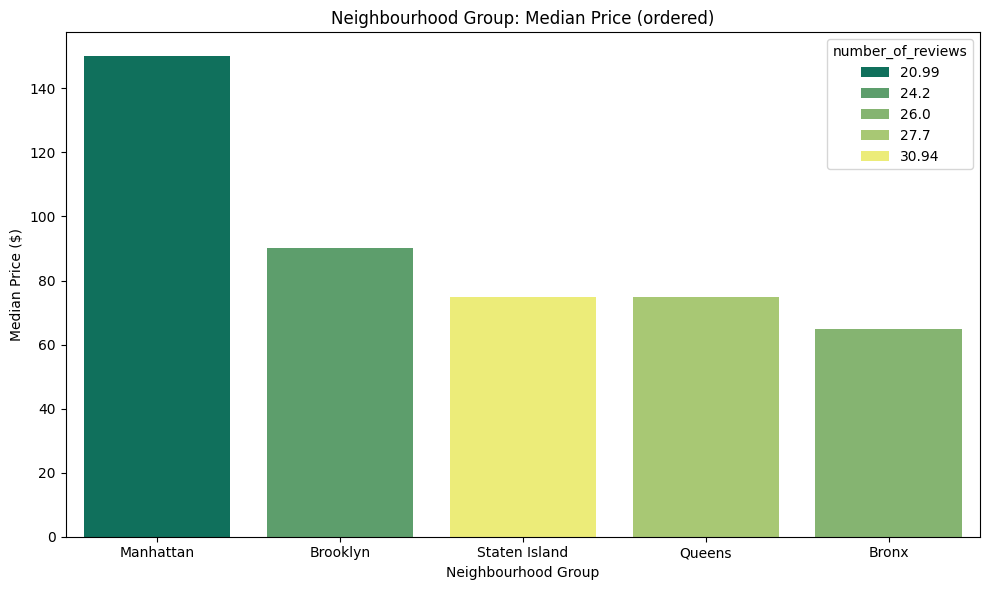

In [ ]:
## neighbourhood groups price — Fixed: sort_values now assigned back to neigbP
neigbP = airbnb_listings.groupby('neighbourhood_group')[['price', 'number_of_reviews']].agg({'price':'median','number_of_reviews':'mean'})
neigbP['number_of_reviews'] = neigbP['number_of_reviews'].round(2)
neigbP = neigbP.sort_values(by=['price', 'number_of_reviews'], ascending=False)

plt.figure(figsize=(10,6))
plt.title('Neighbourhood Group: Median Price (ordered)')
sns.barplot(neigbP, x=neigbP.index, y='price', hue='number_of_reviews', palette='summer')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.show()

In [149]:
## Is the availability affected on the room price? (correlation)
airbnb_listings.corr(numeric_only=True).loc[['log_price', 'availability_365'] , ['log_price', 'availability_365']]

,log_price,availability_365
log_price,1.000000,0.098558
availability_365,0.098558,1.000000


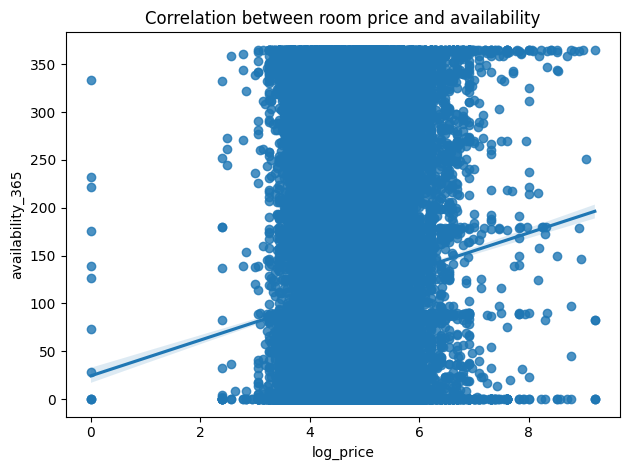

In [150]:
plt.title('Correlation between room price and availability')
sns.regplot(airbnb_listings, y='availability_365', x='log_price')
plt.tight_layout()
plt.show()

### Correlation Heatmap Insights
The heatmap reveals the relationships between all numeric variables simultaneously.
- `log_price` shows very weak correlations with most features, confirming price is driven by qualitative factors (room type, location).
- `number_of_reviews` and `reviews_per_month` are naturally strongly correlated.
- `availability_365` shows a mild positive link with `number_of_reviews`, suggesting more-available listings tend to get reviewed more.

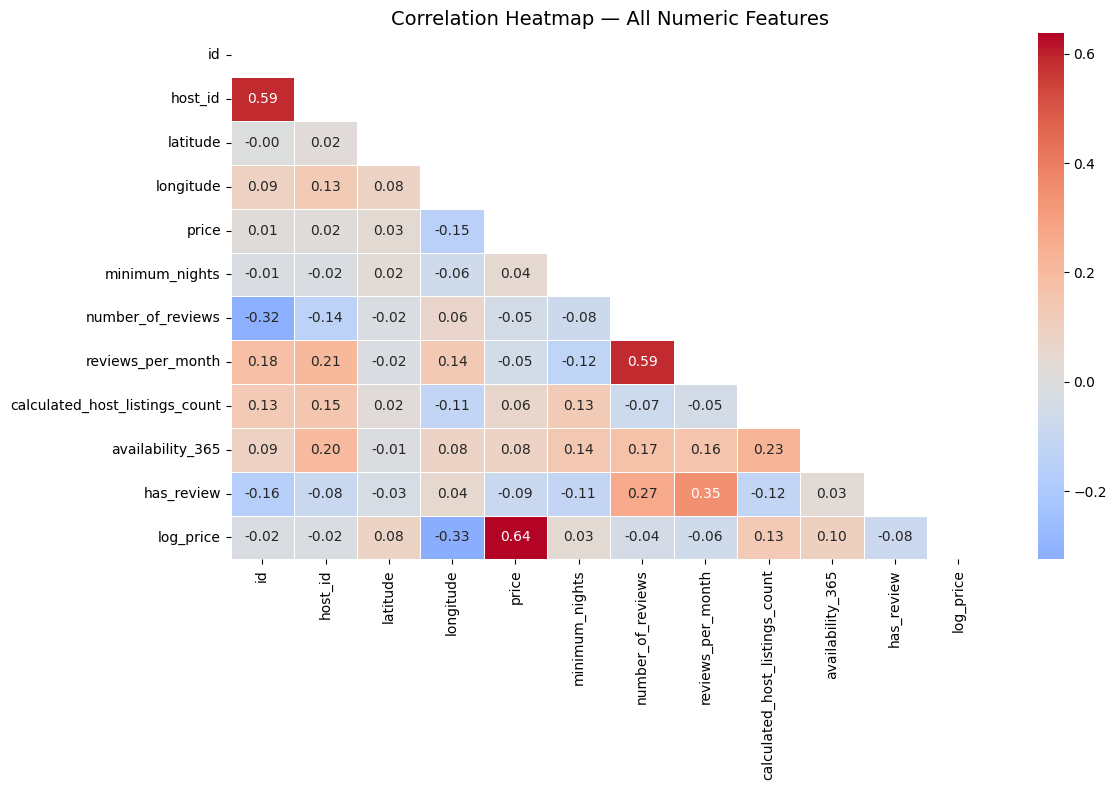

In [ ]:
## Full Correlation Heatmap — added as improvement
plt.figure(figsize=(12, 8))
corr_matrix = airbnb_listings.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

## 🗺️ Geospatial Analysis — Price Distribution Across NYC
Using latitude/longitude from the dataset to visualize where listings are concentrated and how prices vary by location.

In [154]:
## Geospatial analysis using folium — new addition
import folium
from folium.plugins import HeatMap

# Sample for performance (full dataset is 48k rows)
sample = airbnb_listings[airbnb_listings['price'] <= 500].sample(5000, random_state=42)

# Base map centered on NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')

# Heatmap layer based on price intensity
heat_data = list(zip(sample['latitude'], sample['longitude'], sample['log_price']))
HeatMap(heat_data, radius=8, blur=10, min_opacity=0.4).add_to(nyc_map)

# Save to HTML
nyc_map.save('nyc_airbnb_map.html')
print("Map saved! Open nyc_airbnb_map.html to view.")
print(f"Sample size: {len(sample)} listings plotted")
print(f"Price range shown: $0 - $500")

Map saved! Open nyc_airbnb_map.html to view.
Sample size: 5000 listings plotted
Price range shown: $0 - $500


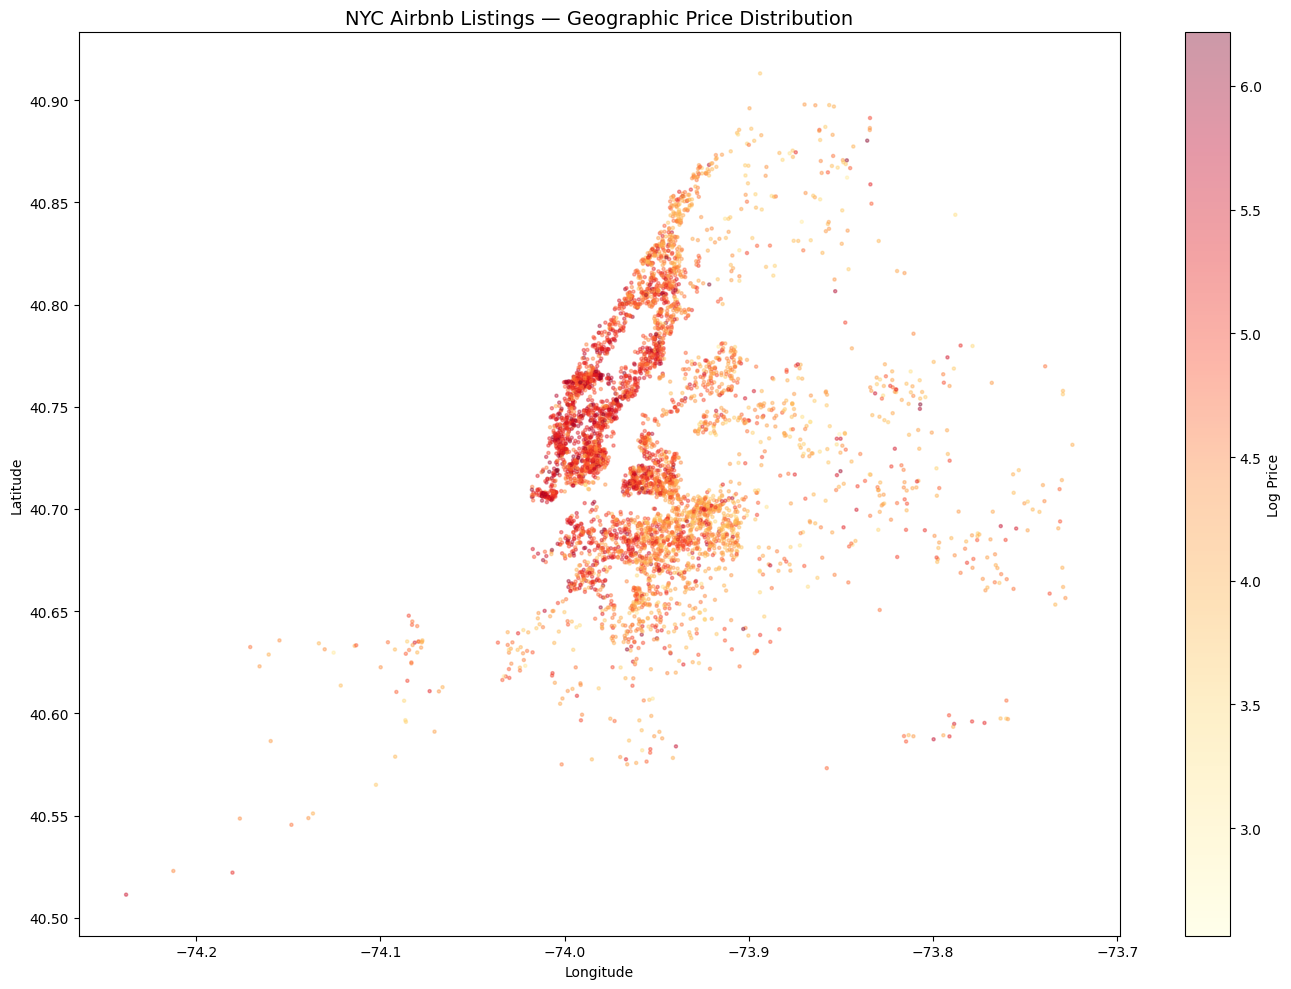

In [155]:
## Scatter plot: geographic price distribution (static version)
plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    sample['longitude'],
    sample['latitude'],
    c=sample['log_price'],
    cmap='YlOrRd',
    alpha=0.4,
    s=5
)

plt.colorbar(scatter, label='Log Price')
plt.title('NYC Airbnb Listings — Geographic Price Distribution', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Geospatial Insights
- **Manhattan** shows the highest density of high-priced listings (darker red in the heatmap).
- **Brooklyn** has a healthy mix of mid-range listings, especially near Manhattan-adjacent neighborhoods.
- **The Bronx, Queens, and Staten Island** are dominated by lower-priced listings.
- This confirms our earlier neighbourhood analysis: **location is the #1 pricing driver**.

## Exploratory Data Analysis

### Price Distribution

Initial analysis showed that listing prices were highly right-skewed, with the majority of prices concentrated between low and mid-range values, while a smaller number of luxury listings created extreme upper-tail values.

To better understand distribution patterns, a log transformation was applied, which normalized the spread and improved interpretability.

---

### Room Type Analysis

Using grouped analysis and visualization, `Entire home/apartment` listings demonstrated the highest median prices, approximately **$160 USD**.

This suggests that privacy and exclusive property access significantly increase perceived value.

---

### Neighborhood Analysis

Among neighborhood groups, **Manhattan** consistently showed the highest median pricing, around **$150 USD**.

This reinforces the importance of location as a premium pricing driver.

Lower review counts in high-priced areas suggest these listings may attract a distinct customer segment rather than reflecting weaker demand.

---

### Reviews vs Price Relationship

Correlation analysis between price and number of reviews revealed a **very weak positive relationship (r = 0.09)**.

This indicates that pricing alone has minimal direct influence on review volume, and customer engagement is likely affected by broader factors such as property type, guest expectations, and travel purpose.


## Key Insights

* Property type strongly impacts pricing, with entire homes commanding the highest rates (~$160 median).
* Location is the most important pricing driver — Manhattan listings are consistently highest priced (~$150 median).
* Review count is **not** a strong predictor of price (r = 0.09).
* Luxury listings represent a meaningful market segment and should not be removed as outliers without business context.
* Median is a more reliable measure of central tendency than mean in this dataset due to skewness.
* **Geospatial analysis confirms** that pricing clusters strongly around Manhattan and Brooklyn waterfront areas.
* The correlation heatmap shows most features have weak direct relationships with price — qualitative factors dominate.